# TP3 - Data Warehouse GDELT y análisis multivariante

## 1. Entorno y rutas

In [1]:
from pathlib import Path
import sys
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "src").is_dir():
    BASE_DIR = cwd
elif (cwd.parent / "src").is_dir():
    BASE_DIR = cwd.parent
else:
    raise FileNotFoundError("Ejecutá este notebook desde la raíz del repositorio o desde notebooks/.")
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
DB_PATH = BASE_DIR / "data" / "gdelt.db"
RAW_DIR = BASE_DIR / "data" / "raw"
DB_PATH.parent.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
print("Repositorio:", BASE_DIR)
print("SQLite:", DB_PATH)


Repositorio: C:\workspace\sqlite_test
SQLite: C:\workspace\sqlite_test\data\gdelt.db


## 2. Configuración de ejecución

- `RECREAR_DB=True` **borra permanentemente** `data/gdelt.db`, incluidas las tablas y datos previos. Se encuentra desactivado por defecto.
- `FECHA_INICIO` define siete días consecutivos de publicaciones GDELT.
- `MAX_ARCHIVOS=1` prueba el ETL con un archivo completo. Para procesar toda la semana, cambiar a `None` tras verificar la primera carga.

La ejecución incremental usa claves primarias y un registro de archivos finalizados. Los módulos de carga actuales realizan sus propios `commit`, por lo que, ante una interrupción entre la carga y el registro de finalización, el archivo puede reintentarse; las inserciones idempotentes evitan duplicar eventos.

In [2]:
RECREAR_DB = False  # Cambiar a True SOLO para comenzar desde cero
FECHA_INICIO = "2026-09-28"
MAX_ARCHIVOS = None #1  # None para la semana completa
DESCARGAR_Y_CARGAR = True  # Activar cuando quieras ejecutar la ingesta


## 3. Crear la base de datos y el esquema

In [3]:
from src.schema import crear_tablas, crear_vista_eventos
from src.database import DB_PATH as DB_PATH_MODULO

# Es importante que schema.py y este notebook trabajen sobre el mismo archivo.
DB_PATH_MODULO = Path(DB_PATH_MODULO).resolve()
assert DB_PATH_MODULO == DB_PATH.resolve(), (
    f"Rutas SQLite distintas: notebook={DB_PATH.resolve()} / "
    f"src.database={DB_PATH_MODULO}"
)

if RECREAR_DB and DB_PATH.exists():
    DB_PATH.unlink()
    print("Base anterior eliminada.")

crear_tablas()
crear_vista_eventos()

with sqlite3.connect(DB_PATH) as con:
    con.execute("PRAGMA foreign_keys = ON")
    con.execute("""CREATE TABLE IF NOT EXISTS ETL_Archivos (
        Archivo TEXT PRIMARY KEY,
        FechaCarga TEXT NOT NULL DEFAULT CURRENT_TIMESTAMP,
        FilasLeidas INTEGER NOT NULL
    )""")
    con.commit()
    objetos = {
        nombre: tipo
        for nombre, tipo in con.execute(
            "SELECT name, type FROM sqlite_master WHERE type IN ('table', 'view')"
        )
    }

requeridos = {
    "Dim_Actor", "Dim_Tiempo", "Dim_Interaccion", "Dim_Geografia",
    "Fact_Evento", "ETL_Archivos", "Vista_Eventos",
}
faltantes = requeridos - objetos.keys()
if faltantes:
    raise RuntimeError(
        f"Faltan tablas o vistas en {DB_PATH}: {sorted(faltantes)}. "
        "Revisá la implementación de crear_tablas() y crear_vista_eventos() en src/schema.py."
    )
print("Esquema verificado:", ", ".join(sorted(requeridos)))


Esquema verificado: Dim_Actor, Dim_Geografia, Dim_Interaccion, Dim_Tiempo, ETL_Archivos, Fact_Evento, Vista_Eventos


**Comprobación obligatoria:** la celda anterior verifica que `src/database.py` y el notebook utilicen el mismo `gdelt.db` y que existan todas las tablas y la vista. Si falla, no continúes con la ingesta: hay que corregir `src/schema.py` o sus rutas.


## 4. Obtener archivos de la semana

In [4]:
from src.ingestion import listar_archivos_semana, descargar_eventos, leer_eventos

# El listado no descarga archivos ZIP; solo consulta el índice de GDELT.
urls_semana = listar_archivos_semana(FECHA_INICIO)
print("Archivos de eventos encontrados:", len(urls_semana))
print("Primero:", urls_semana[0] if urls_semana else "(ninguno)")
print("Último:", urls_semana[-1] if urls_semana else "(ninguno)")


Archivos de eventos encontrados: 672
Primero: http://data.gdeltproject.org/gdeltv2/20260928000000.export.CSV.zip
Último: http://data.gdeltproject.org/gdeltv2/20261004234500.export.CSV.zip


## 5. ETL incremental

Las transformaciones y cargas permanecen en `src/transform.py` y `src/load.py`. Cada archivo se procesa completo, sin `nrows=5`. Se omiten archivos registrados como completados. **No se utiliza la carga ficticia de `seed.py`.**

In [5]:
from src.transform import (
    transformar_actores, asociar_actores,
    transformar_tiempo, asociar_tiempo,
    transformar_interacciones, asociar_interaccion,
    transformar_geografia, asociar_geografia,
    transformar_hechos,
)
from src.load import (
    cargar_dim_actor, cargar_dim_tiempo,
    cargar_dim_interaccion, cargar_dim_geografia,
    cargar_fact_evento,
)


def leer_dimension(nombre_tabla):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql_query(f"SELECT * FROM {nombre_tabla}", con)


def procesar_archivo(url):
    nombre = url.rsplit("/", 1)[-1]
    with sqlite3.connect(DB_PATH) as con:
        procesado = con.execute(
            "SELECT 1 FROM ETL_Archivos WHERE Archivo = ?", (nombre,)
        ).fetchone()
    if procesado:
        print("Omitido (ya procesado):", nombre)
        return "omitido"

    # descargar_eventos() en el proyecto recibe una URL y devuelve el ZIP local.
    archivo_zip = descargar_eventos(url)
    df = leer_eventos(archivo_zip, nrows=None)
    if df.empty:
        raise ValueError(f"Archivo sin eventos: {nombre}")

    cargar_dim_actor(transformar_actores(df))
    cargar_dim_tiempo(transformar_tiempo(df))
    cargar_dim_interaccion(transformar_interacciones(df))
    cargar_dim_geografia(transformar_geografia(df))

    eventos = asociar_actores(df, leer_dimension("Dim_Actor"))
    eventos = asociar_tiempo(eventos)
    eventos = asociar_interaccion(eventos)
    eventos = asociar_geografia(eventos, leer_dimension("Dim_Geografia"))
    hechos = transformar_hechos(eventos)
    cargar_fact_evento(hechos)

    # Marcar como completo solo después de que todas las cargas terminaron.
    with sqlite3.connect(DB_PATH) as con:
        con.execute(
            "INSERT OR IGNORE INTO ETL_Archivos (Archivo, FilasLeidas) VALUES (?, ?)",
            (nombre, len(df)),
        )
        con.commit()
    print(f"Procesado: {nombre} | filas: {len(df)}")
    return "procesado"


**Compatibilidad con el repositorio:** si `descargar_eventos()` tiene una firma distinta (por ejemplo, requiere la carpeta de destino), adaptá esa llamada a la firma real. La carga semanal debe probarse primero con un solo ZIP.

In [6]:
if DESCARGAR_Y_CARGAR:
    pendientes = urls_semana if MAX_ARCHIVOS is None else urls_semana[:MAX_ARCHIVOS]
    for i, url in enumerate(pendientes, start=1):
        print(f"[{i}/{len(pendientes)}]", end=" ")
        procesar_archivo(url)
else:
    print("Ingesta desactivada. Cambiá DESCARGAR_Y_CARGAR=True cuando estés listo.")


[1/672] Omitido (ya procesado): 20260928000000.export.CSV.zip
[2/672] Omitido (ya procesado): 20260928001500.export.CSV.zip
[3/672] Omitido (ya procesado): 20260928003000.export.CSV.zip
[4/672] Omitido (ya procesado): 20260928004500.export.CSV.zip
[5/672] Omitido (ya procesado): 20260928010000.export.CSV.zip
[6/672] Omitido (ya procesado): 20260928011500.export.CSV.zip
[7/672] Omitido (ya procesado): 20260928013000.export.CSV.zip
[8/672] Omitido (ya procesado): 20260928014500.export.CSV.zip
[9/672] Omitido (ya procesado): 20260928020000.export.CSV.zip
[10/672] Omitido (ya procesado): 20260928021500.export.CSV.zip
[11/672] Omitido (ya procesado): 20260928023000.export.CSV.zip
[12/672] Omitido (ya procesado): 20260928024500.export.CSV.zip
[13/672] Omitido (ya procesado): 20260928030000.export.CSV.zip
[14/672] Omitido (ya procesado): 20260928031500.export.CSV.zip
[15/672] Omitido (ya procesado): 20260928033000.export.CSV.zip
[16/672] Omitido (ya procesado): 20260928034500.export.CSV.zip
[

## 6. Verificaciones del Data Warehouse

In [7]:
# Ejecutar solo después de completar la sección 3 (creación y verificación del esquema).
with sqlite3.connect(DB_PATH) as con:
    con.execute("PRAGMA foreign_keys = ON")
    resumen = pd.read_sql_query("""
        SELECT
            (SELECT COUNT(*) FROM Fact_Evento) AS Eventos,
            (SELECT COUNT(*) FROM Dim_Actor) AS Actores,
            (SELECT COUNT(*) FROM Dim_Tiempo) AS Fechas,
            (SELECT COUNT(*) FROM Dim_Interaccion) AS Interacciones,
            (SELECT COUNT(*) FROM Dim_Geografia) AS Ubicaciones,
            (SELECT COUNT(*) FROM ETL_Archivos) AS ArchivosProcesados
    """, con)
    problemas_fk = con.execute("PRAGMA foreign_key_check").fetchall()
display(resumen)
print("Violaciones de claves foráneas:", problemas_fk)
if not DESCARGAR_Y_CARGAR:
    print("Aviso: DESCARGAR_Y_CARGAR=False. La base puede estar vacía; activá la ingesta en la sección 2.")


,Eventos,Actores,Fechas,Interacciones,Ubicaciones,ArchivosProcesados
0,683432,4419,35,228,22032,672


Violaciones de claves foráneas: []


## 7. Datos integrados para el análisis

In [8]:
with sqlite3.connect(DB_PATH) as con:
    eventos = pd.read_sql_query("SELECT * FROM Vista_Eventos", con)

print("Eventos:", len(eventos), "| Columnas:", len(eventos.columns))
display(eventos.head())
if eventos.empty:
    print("Todavía no hay eventos reales. Ejecutá la ingesta antes del análisis multivariante.")


Eventos: 683432 | Columnas: 14


,GlobalEventID,Fecha,Actor1,PaisActor1,Actor2,PaisActor2,EventCode,QuadClass,Ubicacion,PaisEvento,AvgTone,GoldsteinScale,NumMentions,NumArticles
0,1325186209,2016-09-30,None,None,DUBAI,ARE,036,1,"Dubai, Dubayy, United Arab Emirates",AE,-1.965812,4.0,20,10
1,1325186210,2016-09-30,None,None,ARMY,None,190,4,"Amana, Iowa, United States",US,-2.356902,-10.0,10,10
2,1325186211,2016-09-30,DUBAI,ARE,None,None,036,1,"Dubai, Dubayy, United Arab Emirates",AE,-1.965812,4.0,20,10
3,1325186212,2016-09-30,ARMY,None,None,None,190,4,"Amana, Iowa, United States",US,-2.356902,-10.0,10,10
4,1325186213,2025-09-28,None,None,NAPLES,ITA,042,1,United States,US,0.324939,1.9,2,2


## 8. Preparación de la matriz multivariante

Seleccionamos `AvgTone`, `GoldsteinScale`, los países de ambos actores, el tipo de interacción (`EventCode`) y el país del evento. Las categorías con frecuencia **estrictamente menor al 5 %** se agrupan en `OTHER` antes de generar variables dummy. Las filas sin valores numéricos válidos se descartan. El índice original se conserva para poder vincular cada fila con su país y con su evento GDELT.

**Alcance:** los resultados describen los archivos efectivamente cargados en SQLite. Si `MAX_ARCHIVOS=1`, corresponden a un único intervalo de 15 minutos, no a toda la semana.

In [9]:
from src.preprocessing import preparar_datos

df, df_dummies = preparar_datos(
    eventos,
    umbral=0.05
)

print("Datos categóricos:", df.shape)
print("Matriz numérica:", df_dummies.shape)

display(df.head())
display(df_dummies.head())

Datos categóricos: (683432, 6)
Matriz numérica: (683432, 19)


,PaisActor1,PaisActor2,EventCode,PaisEvento,AvgTone,GoldsteinScale
0,UNKNOWN,OTHER,OTHER,OTHER,-1.965812,4.0
1,UNKNOWN,UNKNOWN,OTHER,US,-2.356902,-10.0
2,OTHER,UNKNOWN,OTHER,OTHER,-1.965812,4.0
3,UNKNOWN,UNKNOWN,OTHER,US,-2.356902,-10.0
4,UNKNOWN,OTHER,042,US,0.324939,1.9


,AvgTone,GoldsteinScale,PaisActor1_OTHER,PaisActor1_UNKNOWN,PaisActor1_USA,PaisActor2_OTHER,PaisActor2_UNKNOWN,PaisActor2_USA,EventCode_010,EventCode_020,EventCode_040,EventCode_042,EventCode_043,EventCode_051,EventCode_OTHER,PaisEvento_IN,PaisEvento_OTHER,PaisEvento_UK,PaisEvento_US
0,-1.965812,4.0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0
1,-2.356902,-10.0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,-1.965812,4.0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0
3,-2.356902,-10.0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
4,0.324939,1.9,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1


### 8.1. Verificación de la matriz y de las categorías agrupadas

Las columnas dummy representan proporciones al calcular sus medias. Una categoría rara pasa a `OTHER` dentro de cada variable categórica, por lo que `OTHER` no identifica un país específico.

In [10]:
if df_dummies.empty:
    raise ValueError("La matriz está vacía. Revisá la ingesta y la sección 8.")

print(f"Eventos originales: {len(eventos):,}")
print(f"Eventos válidos: {len(df_dummies):,}")
print(f"Variables numéricas y dummy: {df_dummies.shape[1]}")
print("Valores faltantes:", int(df_dummies.isna().sum().sum()))

for variable in ["PaisActor1", "PaisActor2", "EventCode", "PaisEvento"]:
    print(f"\n{variable}: categorías agrupadas")
    display(df[variable].value_counts().rename("n").to_frame().head(12))


Eventos originales: 683,432
Eventos válidos: 683,432
Variables numéricas y dummy: 19
Valores faltantes: 0

PaisActor1: categorías agrupadas


,n
PaisActor1,
UNKNOWN,304077
OTHER,263742
USA,115613



PaisActor2: categorías agrupadas


,n
PaisActor2,
UNKNOWN,389083
OTHER,213286
USA,81063



EventCode: categorías agrupadas


,n
EventCode,
OTHER,391438
010,61153
042,53888
043,50651
040,42606
020,42416
051,41280



PaisEvento: categorías agrupadas


,n
PaisEvento,
OTHER,392756
US,211914
IN,40709
UK,38053


## 9. Estadística descriptiva y comparación entre países

Calculamos el vector de medias global y los vectores medios por país del **evento** (`PaisEvento`, sin agrupar en `OTHER`). Las medias de las dummies representan la proporción de eventos de cada categoría dentro del grupo.

Para comparar distancias euclidianas, estandarizamos primero las variables a nivel de **evento**, de modo que `AvgTone` y `GoldsteinScale` no dominen las distancias por sus escalas.

In [11]:
from src.statistics import (
    resumen_global, vector_medias, matriz_covarianza, matriz_correlacion,
    medias_por_pais, distancias_entre_paises, correlaciones_por_pais,
)
from src.pca_analysis import estandarizar_datos
from src.visualization import (
    plot_correlation_heatmap, plot_distance_heatmap,
    plot_scree, plot_biplot,
)

# País original, no el país agrupado del preprocesamiento.
pais_evento = eventos.loc[df_dummies.index, "PaisEvento"].copy()
pais_evento = pais_evento.astype("string").fillna("UNKNOWN").str.strip().replace("", "UNKNOWN")

print("Estadísticos globales:")
display(resumen_global(df_dummies).round(3))
print("Vector de medias globales (primeras variables):")
display(vector_medias(df_dummies).head(20).round(3).to_frame("media_global"))


Estadísticos globales:


,media,desvio,n
AvgTone,-1.966,4.125,683432
GoldsteinScale,0.523,4.562,683432
PaisActor1_OTHER,0.386,0.487,683432
PaisActor1_UNKNOWN,0.445,0.497,683432
PaisActor1_USA,0.169,0.375,683432
PaisActor2_OTHER,0.312,0.463,683432
PaisActor2_UNKNOWN,0.569,0.495,683432
PaisActor2_USA,0.119,0.323,683432
EventCode_010,0.089,0.285,683432
EventCode_020,0.062,0.241,683432


Vector de medias globales (primeras variables):


,media_global
AvgTone,-1.966
GoldsteinScale,0.523
PaisActor1_OTHER,0.386
PaisActor1_UNKNOWN,0.445
PaisActor1_USA,0.169
PaisActor2_OTHER,0.312
PaisActor2_UNKNOWN,0.569
PaisActor2_USA,0.119
EventCode_010,0.089
EventCode_020,0.062


### 9.1. Medias por país

Para evitar que países con uno o dos eventos produzcan resultados inestables, se exige una cantidad mínima de eventos por país. El umbral se puede modificar y debe reportarse en la entrega.

In [12]:
MIN_EVENTOS_PAIS = 30
TOP_PAISES = 12

medias_pais, conteos_pais = medias_por_pais(
    df_dummies, pais_evento,
    minimo_eventos=MIN_EVENTOS_PAIS,
    excluir_unknown=True,
)
print("Países con suficientes eventos:", len(medias_pais))
display(conteos_pais.rename("n_eventos").to_frame().head(20))

if not medias_pais.empty:
    resumen_paises = medias_pais[["AvgTone", "GoldsteinScale"]].copy()
    resumen_paises.insert(0, "n_eventos", conteos_pais)
    display(resumen_paises.head(20).round(3))
else:
    print("No hay países con el mínimo requerido. Revisá MIN_EVENTOS_PAIS o cargá más archivos.")


Países con suficientes eventos: 210


,n_eventos
PaisEvento,
US,211914
IN,40709
UK,38053
IS,28065
NI,27802
CA,19308
CH,16122
IR,15464
AS,13573


,n_eventos,AvgTone,GoldsteinScale
PaisEvento,,,
US,211914,-2.128,0.480
IN,40709,-2.125,0.162
UK,38053,-1.704,0.641
IS,28065,-3.827,-0.520
NI,27802,-0.761,0.787
CA,19308,-0.541,1.240
CH,16122,-0.478,1.324
IR,15464,-3.727,-0.111
AS,13573,-1.339,0.684


### 9.2. Distancias entre vectores medios

Se calcula la distancia euclidiana entre los vectores medios de los países más representados, utilizando la matriz de eventos estandarizada. Esta distancia refleja diferencias descriptivas entre perfiles de eventos, **no** distancias geográficas.

PaisEvento,US,IN,UK,IS,NI,CA,CH,IR,AS,RS,PK,FR
PaisEvento,,,,,,,,,,,,
US,0.00,4.99,5.17,3.65,3.45,3.40,3.45,3.47,3.41,3.74,3.49,3.48
IN,4.99,0.00,6.14,4.94,4.74,4.79,4.89,4.91,4.75,5.00,4.78,4.82
UK,5.17,6.14,0.00,4.88,4.83,4.82,4.84,4.88,4.81,4.91,4.83,4.81
IS,3.65,4.94,4.88,0.00,1.28,1.15,1.00,0.42,1.05,0.27,0.66,0.72
NI,3.45,4.74,4.83,1.28,0.00,0.41,0.86,1.26,0.33,1.41,0.78,0.67
CA,3.40,4.79,4.82,1.15,0.41,0.00,0.50,1.08,0.31,1.25,0.78,0.47
CH,3.45,4.89,4.84,1.00,0.86,0.50,0.00,0.91,0.69,1.03,0.91,0.51
IR,3.47,4.91,4.88,0.42,1.26,1.08,0.91,0.00,1.02,0.51,0.68,0.74
AS,3.41,4.75,4.81,1.05,0.33,0.31,0.69,1.02,0.00,1.18,0.57,0.43


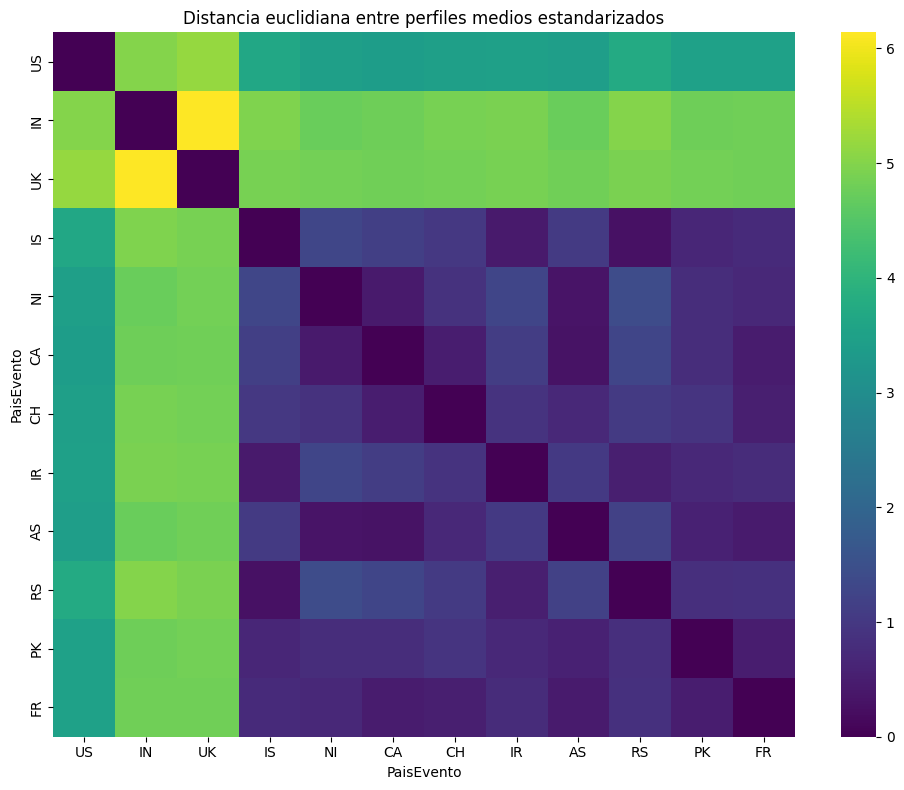

Pares de países con perfiles más parecidos:


distancia
PaisEvento PaisEvento           
IS         RS           0.267183
CA         AS           0.305098
NI         AS           0.327078
           CA           0.412777
IS         IR           0.419164
AS         FR           0.432112
CA         FR           0.468385
           CH           0.496012
PK         FR           0.497092
CH         FR           0.510545

Pares con perfiles más diferentes:


distancia
PaisEvento PaisEvento           
IN         UK           6.139965
US         UK           5.169965
IN         RS           4.999900
US         IN           4.988736
IN         IS           4.943205
           IR           4.913603
UK         RS           4.909822
IN         CH           4.886388
UK         IS           4.884974
           IR           4.881685

In [13]:
z_eventos, _ = estandarizar_datos(df_dummies)
medias_z, conteos_z = medias_por_pais(
    z_eventos, pais_evento,
    minimo_eventos=MIN_EVENTOS_PAIS,
    excluir_unknown=True,
)
paises_comparados = conteos_z.head(TOP_PAISES).index

if len(paises_comparados) >= 2:
    distancias_paises = distancias_entre_paises(medias_z.loc[paises_comparados])
    display(distancias_paises.round(2))
    fig = plot_distance_heatmap(distancias_paises, titulo="Distancia euclidiana entre perfiles medios estandarizados")
    plt.show()
    pares = distancias_paises.where(
        np.triu(np.ones(distancias_paises.shape, dtype=bool), k=1)
    ).stack().sort_values()
    print("Pares de países con perfiles más parecidos:")
    display(pares.head(10).rename("distancia").to_frame())
    print("Pares con perfiles más diferentes:")
    display(pares.tail(10).sort_values(ascending=False).rename("distancia").to_frame())
else:
    print("Se necesitan al menos dos países con suficientes eventos para comparar distancias.")


## 10. Correlaciones globales y por país

La correlación de Pearson muestra asociaciones lineales entre variables. Para mantener legibles los mapas de calor, visualizamos las dos variables numéricas y las dummies de mayor frecuencia. Las correlaciones entre dummies mutuamente excluyentes deben interpretarse con cuidado, pues su codificación induce relaciones negativas.

Matriz de correlación global completa: (19, 19)


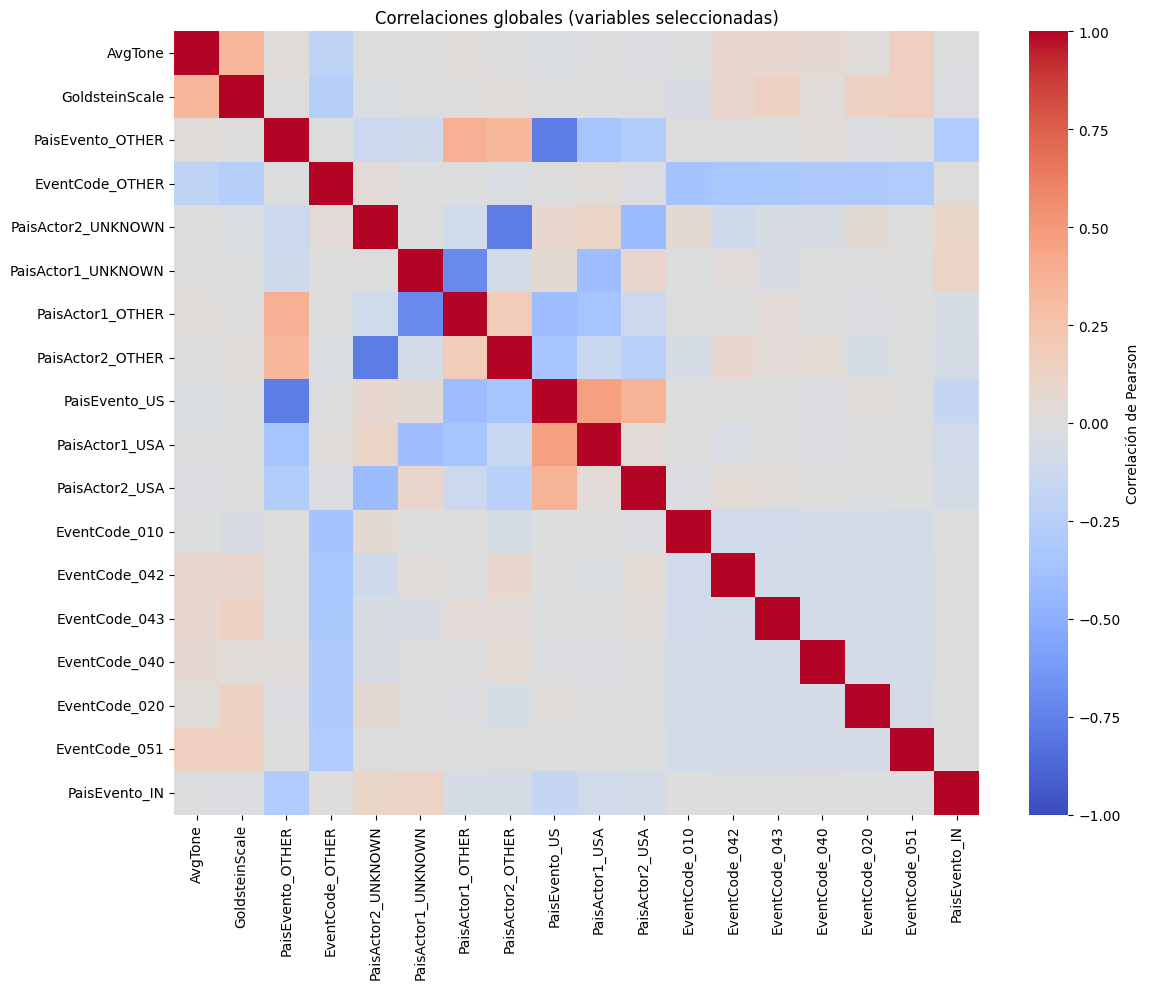

Correlación entre las variables numéricas:


,AvgTone,GoldsteinScale
AvgTone,1.000,0.343
GoldsteinScale,0.343,1.000


In [14]:
corr_global = matriz_correlacion(df_dummies)
print("Matriz de correlación global completa:", corr_global.shape)

MAX_VARIABLES_HEATMAP = 18
cols_base = [c for c in ["AvgTone", "GoldsteinScale"] if c in df_dummies.columns]
cols_dummy = [c for c in df_dummies.columns if c not in cols_base]
cols_dummy = sorted(cols_dummy, key=lambda c: float(df_dummies[c].mean()), reverse=True)
cols_heatmap = cols_base + cols_dummy[:max(0, MAX_VARIABLES_HEATMAP - len(cols_base))]

fig = plot_correlation_heatmap(
    corr_global.loc[cols_heatmap, cols_heatmap],
    titulo="Correlaciones globales (variables seleccionadas)",
    figsize=(12, 10),
)
plt.show()

print("Correlación entre las variables numéricas:")
display(corr_global.loc[cols_base, cols_base].round(3))


### 10.1. Correlaciones por país

Comparamos las matrices de los países con más observaciones. Si una variable es constante dentro de un país, su correlación aparece como `NaN`: no debe interpretarse como cero.

País: US | eventos: 211914


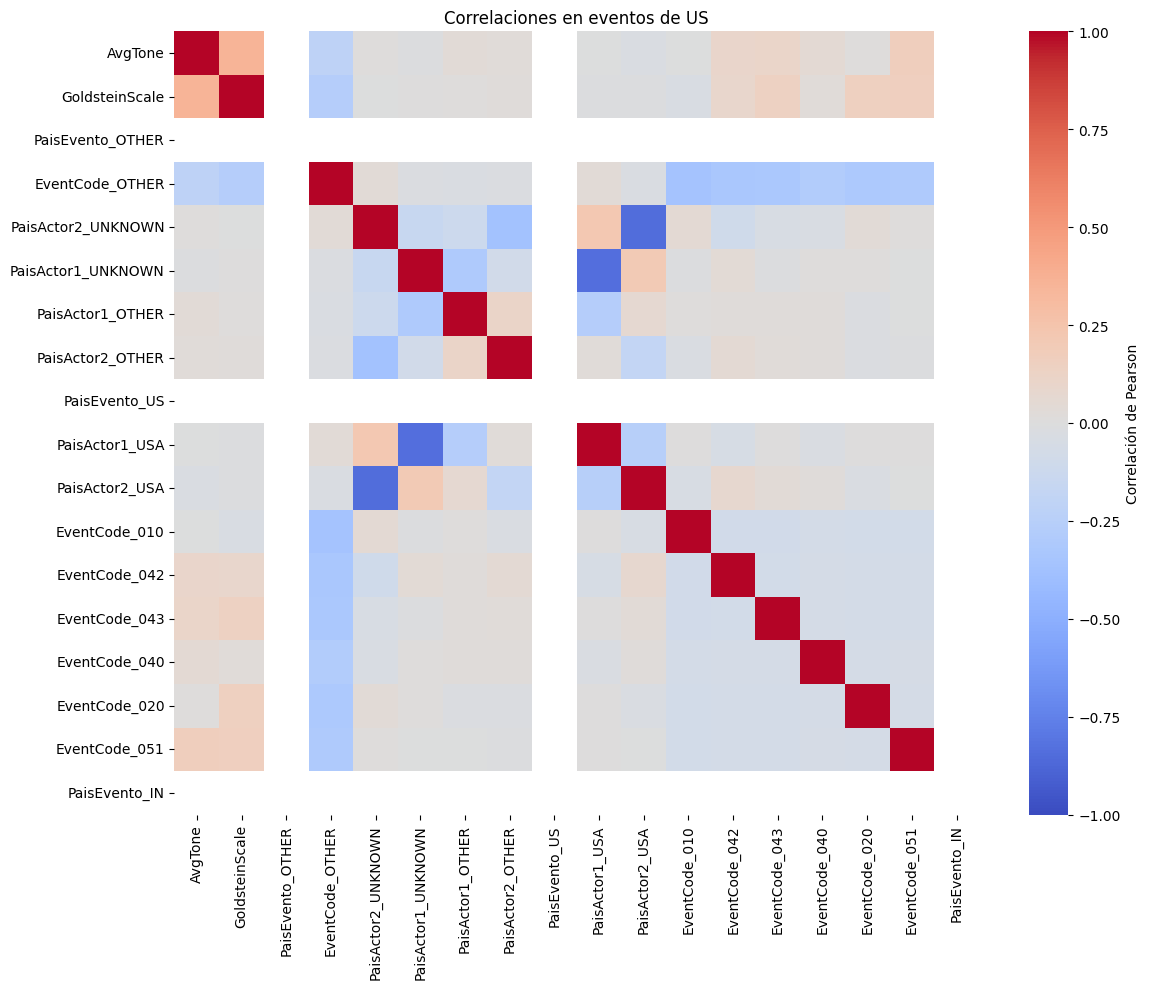

País: IN | eventos: 40709


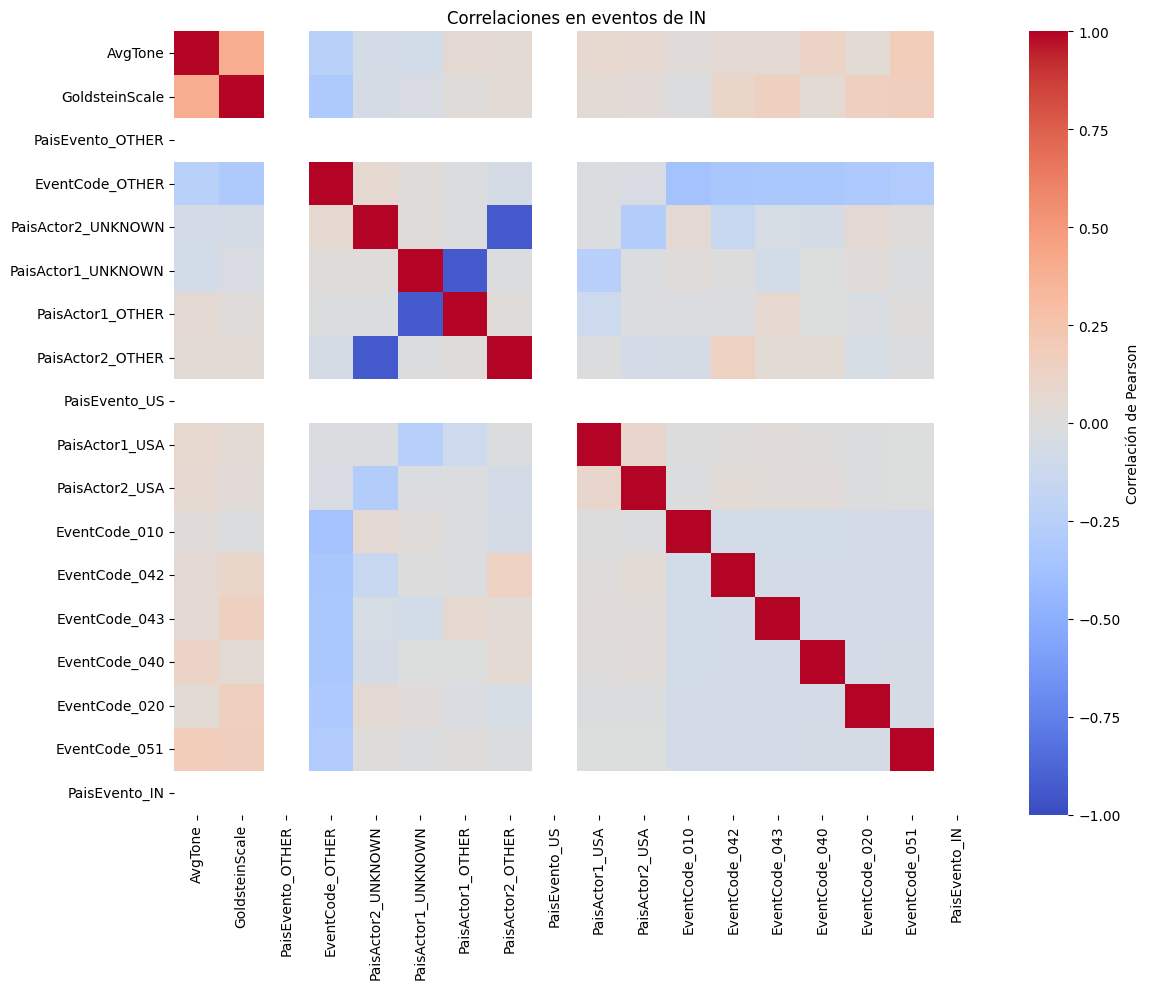

País: UK | eventos: 38053


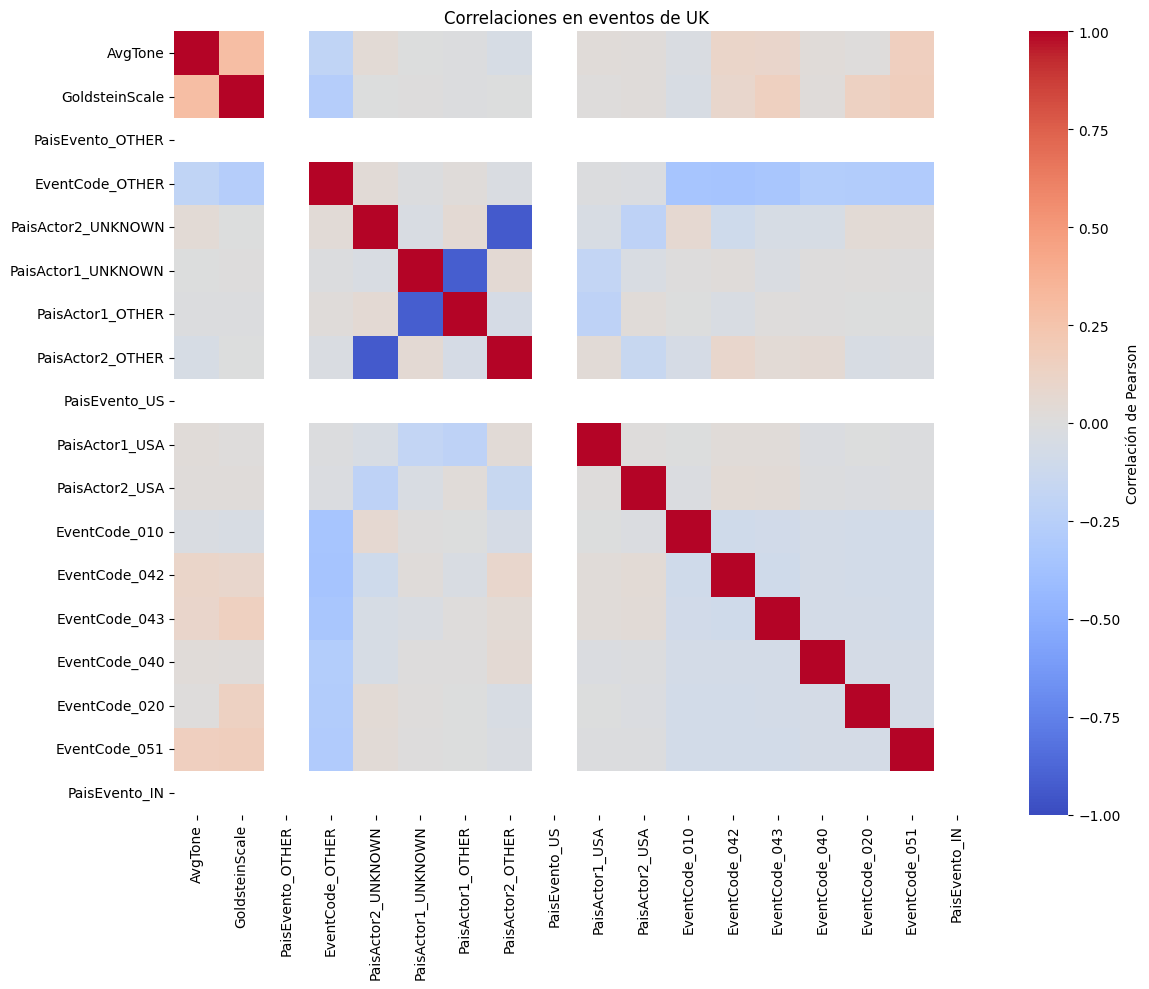

In [15]:
correlaciones_paises = correlaciones_por_pais(
    df_dummies, pais_evento, minimo_eventos=MIN_EVENTOS_PAIS
)

for pais in [p for p in conteos_pais.head(3).index if p in correlaciones_paises]:
    corr_pais = correlaciones_paises[pais].loc[cols_heatmap, cols_heatmap]
    print(f"País: {pais} | eventos: {int(conteos_pais[pais])}")
    fig = plot_correlation_heatmap(
        corr_pais, titulo=f"Correlaciones en eventos de {pais}", figsize=(12, 10)
    )
    plt.show()

if not correlaciones_paises:
    print("No hay países con suficientes observaciones para calcular matrices por país.")


## 11. Análisis de componentes principales (PCA)

Se estandariza cada variable (media cero, desvío estándar uno) y se descartan las columnas constantes. El PCA identifica combinaciones lineales ortogonales que maximizan la varianza. El signo de cada componente es arbitrario; la interpretación se apoya en los *loadings* y no solamente en el signo.

**Nota metodológica:** el PCA incluye dummies de categorías completas. Por eso puede haber dependencias lineales entre columnas, y algunas componentes finales pueden tener autovalores cercanos a cero.

In [16]:
from src.pca_analysis import run_pca, principales_loadings, observaciones_extremas

resultado_pca = run_pca(df_dummies)
print("Variables originales:", df_dummies.shape[1])
print("Variables utilizadas:", resultado_pca.loadings.shape[0])
print("Columnas constantes descartadas:", resultado_pca.columnas_descartadas)

varianza = resultado_pca.variance_table()
display(varianza.head(20).round(4))

print(f"Varianza explicada por PC1: {resultado_pca.var_exp[0]:.2%}")
print(f"Varianza acumulada PC1+PC2: {resultado_pca.var_acum[1]:.2%}")
print("Componentes para explicar al menos el 80 %:", int(np.searchsorted(resultado_pca.var_acum, 0.80) + 1))


Variables originales: 19
Variables utilizadas: 19
Columnas constantes descartadas: []


,autovalor,varianza_explicada,varianza_acumulada
componente,,,
PC1,2.8411,0.1495,0.1495
PC2,1.9502,0.1026,0.2522
PC3,1.7459,0.0919,0.3441
PC4,1.6475,0.0867,0.4308
PC5,1.2277,0.0646,0.4954
PC6,1.1948,0.0629,0.5583
PC7,1.0873,0.0572,0.6155
PC8,1.0787,0.0568,0.6723
PC9,1.0742,0.0565,0.7288


Varianza explicada por PC1: 14.95%
Varianza acumulada PC1+PC2: 25.22%
Componentes para explicar al menos el 80 %: 11


### 11.1. Scree plot

El gráfico muestra los autovalores y la varianza acumulada. Se utiliza para justificar cuántas componentes conservar, junto con la interpretabilidad de los ejes.

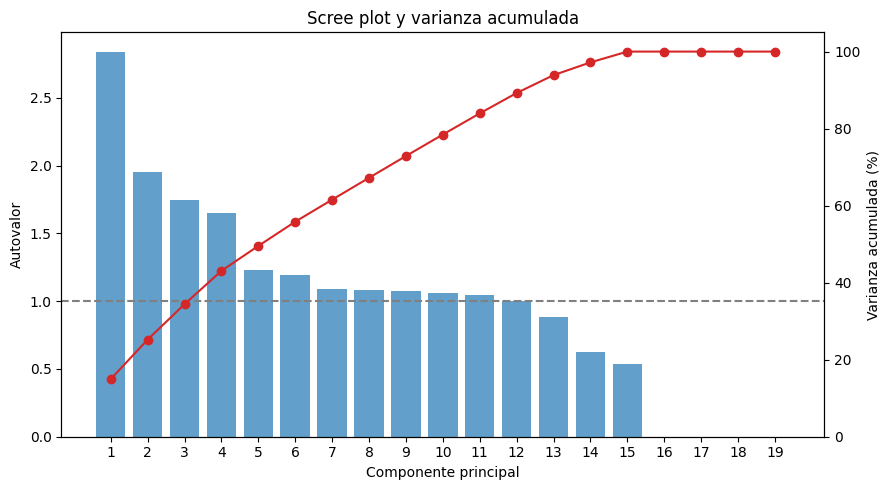

In [17]:
fig = plot_scree(resultado_pca.eigenvalues, resultado_pca.var_exp)
plt.show()


### 11.2. Loadings: interpretación de PC1 y PC2

Los *loadings* indican la correlación de cada variable original estandarizada con cada componente. Observamos los valores de mayor magnitud (positivos y negativos) y proponemos una interpretación conceptual de cada eje a partir de las variables dominantes.

In [18]:
for componente in ["PC1", "PC2"]:
    print(f"\nVariables más asociadas a {componente}:")
    display(principales_loadings(resultado_pca, componente=componente, n=15).round(3).to_frame("loading"))

print("Loadings de AvgTone y GoldsteinScale:")
filas = [c for c in ["AvgTone", "GoldsteinScale"] if c in resultado_pca.loadings.index]
display(resultado_pca.loadings.loc[filas, ["PC1", "PC2"]].round(3))



Variables más asociadas a PC1:


,loading
PaisEvento_US,0.835
PaisEvento_OTHER,-0.812
PaisActor1_OTHER,-0.671
PaisActor2_OTHER,-0.636
PaisActor1_USA,0.520
PaisActor2_UNKNOWN,0.366
PaisActor2_USA,0.351
PaisActor1_UNKNOWN,0.265
PaisEvento_IN,0.091
EventCode_OTHER,0.066



Variables más asociadas a PC2:


,loading
EventCode_OTHER,0.834
GoldsteinScale,-0.603
AvgTone,-0.525
EventCode_051,-0.350
EventCode_042,-0.338
EventCode_043,-0.330
EventCode_020,-0.245
PaisActor2_UNKNOWN,0.227
EventCode_040,-0.224
PaisActor2_USA,-0.187


Loadings de AvgTone y GoldsteinScale:


,PC1,PC2
AvgTone,-0.064,-0.525
GoldsteinScale,-0.054,-0.603


**Interpretación para completar luego de ejecutar:** ¿qué variables tienen mayor loading absoluto en PC1? ¿Representan principalmente diferencias en tono/impacto o contrastes entre países y tipos de interacción? Repetí el razonamiento para PC2. Evitá asignar nombres a los ejes antes de observar los resultados.

## 12. Biplot PC1–PC2 y observaciones atípicas

Cada punto representa un evento. Las flechas corresponden a las variables con mayor asociación con las dos primeras componentes. Los colores identifican el país del evento (agrupando visualmente los países menos frecuentes). Las flechas se escalan para facilitar la visualización.

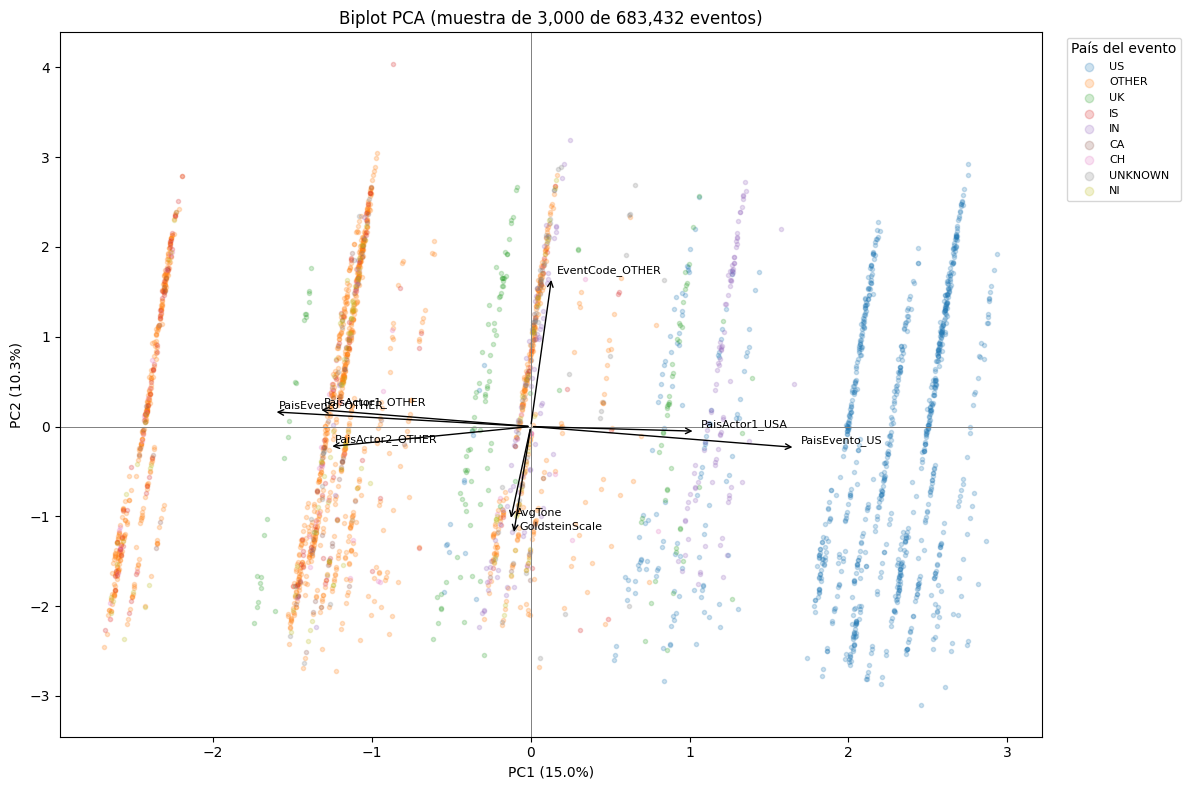

In [21]:
import importlib
import src.visualization as viz

importlib.reload(viz)

fig = viz.plot_biplot(
    resultado_pca.scores,
    resultado_pca.loadings,
    grupos=pais_evento,
    var_exp=resultado_pca.var_exp,
    max_puntos=3000,
    max_flechas=8,
    alpha=0.22,
    figsize=(12, 8)
)

plt.show()


### 12.1. Eventos más alejados del origen en PC1–PC2

La distancia al origen identifica observaciones extremas **en la proyección de dos dimensiones**. No es una prueba estadística formal de anomalías. Recuperamos el ID, la fecha, el país y los indicadores del evento para poder describir casos concretos.

In [22]:
extremos = observaciones_extremas(resultado_pca, n=15)
columnas_contexto = [
    c for c in ["GlobalEventID", "Fecha", "PaisEvento", "Actor1", "Actor2",
              "EventCode", "AvgTone", "GoldsteinScale"] if c in eventos.columns
]
contexto = eventos.loc[extremos.index, columnas_contexto]
reporte_extremos = contexto.join(extremos)
display(reporte_extremos.round(3))


,GlobalEventID,Fecha,PaisEvento,Actor1,Actor2,EventCode,AvgTone,GoldsteinScale,PC1,PC2,distancia_origen
561594,1326084928,2026-10-03,YM,YEMEN,IRAN,182,-29.032,-9.5,-2.048,4.231,4.700
561595,1326084929,2026-10-03,YM,YEMEN,IRAN,182,-29.032,-9.5,-2.048,4.231,4.700
218129,1325539367,2026-09-30,US,TENNESSEE,CRIMINAL,193,-22.222,-10.0,2.831,3.671,4.636
534359,1326046206,2026-10-02,US,UNITED STATES,None,180,-23.148,-9.0,2.833,3.661,4.629
161005,1325450829,2026-09-29,US,UNITED STATES,None,180,-22.472,-9.0,2.826,3.599,4.576
195397,1325506502,2026-09-29,US,UNITED STATES,None,193,-21.333,-10.0,2.823,3.590,4.567
30889,1325238244,2026-09-28,NI,VICTORIA,NIGERIA,051,19.466,3.4,-2.691,-3.673,4.554
31674,1325239029,2026-09-28,NI,NIGERIA,VICTORIA,051,19.466,3.4,-2.691,-3.673,4.554
223256,1325546466,2026-09-30,US,DAKOTA,None,180,-22.115,-9.0,2.823,3.567,4.549
626967,1326194555,2026-10-04,US,GREENVILLE,NORTH CAROLINA,051,12.234,3.4,2.520,-3.743,4.512


### 12.2. Centroides de los países en el espacio PCA

Para facilitar la comparación entre países, se calcula el promedio de las coordenadas PC1 y PC2 de los eventos correspondientes a cada país. El tamaño de cada punto representa la cantidad de eventos considerados.

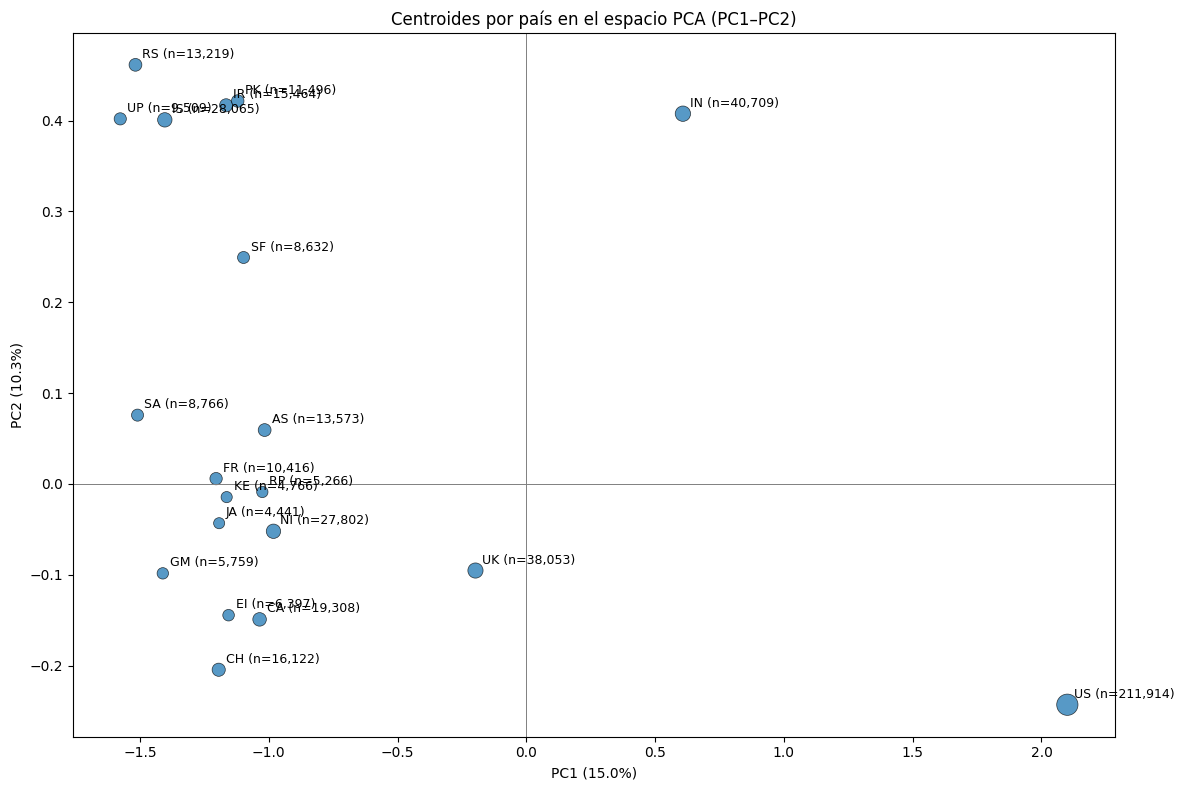

In [23]:
fig = viz.plot_centroides_paises(
    resultado_pca.scores,
    grupos=pais_evento,
    var_exp=resultado_pca.var_exp,
    min_eventos=100,
    max_paises=20,
    figsize=(12, 8)
)

plt.show()

## 13. Síntesis para la entrega del TP3

Completá esta sección **con los resultados obtenidos** tras ejecutar la ingesta deseada:

1. **Cobertura:** cantidad de archivos GDELT procesados, eventos válidos, período y países con suficientes eventos.
2. **Reducción de cardinalidad:** categorías agrupadas en `OTHER` y número final de variables dummy.
3. **Medias y distancias:** países con mayor y menor `AvgTone`/`GoldsteinScale`, y pares de perfiles más cercanos y lejanos (especificando estandarización).
4. **Correlaciones:** asociaciones destacadas en la matriz global y diferencias entre países, evitando interpretar como sustantivas las relaciones inducidas por dummies.
5. **PCA:** varianza explicada por PC1 y PC2, cantidad de componentes para alcanzar 80 %, variables dominantes de cada eje y nombres conceptuales propuestos.
6. **Biplot:** patrones visibles, países destacados y descripción de algunos eventos extremos identificados por `GlobalEventID`.

**Limitaciones:** la cobertura GDELT depende de los archivos descargados; los resultados son descriptivos, y el agrupamiento al 5 % depende de la muestra cargada. Si se utiliza un solo ZIP, no presentar conclusiones como representativas de una semana completa.